<a href="https://colab.research.google.com/github/PallaviCK11/SAM/blob/main/Mini_Project11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# **Project Title**

**Customer Behavior Analysis & Prediction System**



# Business Problem
A wholesale distributor wants to understand customer purchasing behavior and:

1.Predict whether a customer belongs to the Hotel or Retail segment.

2.Identify hidden customer segments for targeted marketing. You are hired as a Data Scientist to build an end‑to‑end ML solution

# **Project Tasks**

## **Part A - Data Understanding**

**Import required libraries**




In [ ]:
# Basic Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

#Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

#Evaluation Matrics
from sklearn.metrics import (
       mean_absolute_error, mean_squared_error, r2_score,
       accuracy_score, precision_score, recall_score, f1_score,
       classification_report, roc_curve, roc_auc_score)

#Unsupervised Learning
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# **Load the dataset and display basic information and data**

In [ ]:
from google.colab import files
uploaded=files.upload()

Saving Wholesale customers data.csv to Wholesale customers data.csv


## **Read the dataset**

In [ ]:
import pandas as pd
df=pd.read_csv('Wholesale customers data.csv')

In [ ]:
#Display column names
df.columns

Index(['Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen'], dtype='object')

# **Identify:Features and target variable**

In [ ]:
# Remove extra spaces from column names
df.columns = df.columns.str.strip()

# Define target variable
target = 'Channel'

# Identify features
if target in df.columns:
    features = df.drop(columns=[target]).columns.tolist()
    print("Target variable:", target)
    print("Feature variables:", features)
else:
    print(f"'{target}' column not found. Available columns:")
    print(df.columns.tolist())

Target variable: Channel
Feature variables: ['Region', 'Fresh', 'Milk', 'Grocery', 'Frozen', 'Detergents_Paper', 'Delicassen', 'Total_Spend', 'Food_Spend', 'Non_Food_Spend']


# **The difference between supervised & unsupervised learning.**

* Supervised Learning:

 In supervised learning the model is train using labelled data
 that is input place output is already given.

* Unsupervised Learning:

 Unsupervised learning is a type of
machine learning where the model is trained on unlabeled
data, and the goal is to identify patterns, relationships, or
groupings within the data without prior knowledge of the
expected output.

# **Part B - Data Processing and Feature Engineering**

**Create at least 3 new meaningful features from existing columns**

In [ ]:
# 1. Total spending by customer
df['Total_Spend'] = (
    df['Fresh'] +
    df['Milk'] +
    df['Grocery'] +
    df['Frozen'] +
    df['Detergents_Paper'] +
    df['Delicassen']
)

# 2. Food related spending
df['Food_Spend'] = (
    df['Fresh'] +
    df['Frozen'] +
    df['Delicassen']
)

# 3. Non-food related spending
df['Non_Food_Spend'] = (
    df['Milk'] +
    df['Grocery'] +
    df['Detergents_Paper']
)

# Display updated dataset
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spend,Food_Spend,Non_Food_Spend
0,2,3,12669,9656,7561,214,2674,1338,34112,14221,19891
1,2,3,7057,9810,9568,1762,3293,1776,33266,10595,22671
2,2,3,6353,8808,7684,2405,3516,7844,36610,16602,20008
3,1,3,13265,1196,4221,6404,507,1788,27381,21457,5924
4,2,3,22615,5410,7198,3915,1777,5185,46100,31715,14385


# **Perform:**

**1.Outlier Detection**


In [ ]:
# Detect and remove outliers using IQR method

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df_clean = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

print("Original Shape:", df.shape)
print("After Outlier Removal:", df_clean.shape)

Original Shape: (440, 11)
After Outlier Removal: (332, 11)


**2.Scaling of numerical features**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

num_cols = df_clean.select_dtypes(include=['float64', 'int64']).columns

df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])

/tmp/ipython-input-2545282842.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])


# **Analyse Multicollinearity using correlation are VIF**
**1.Correlation Matrix**

**2.VIF**

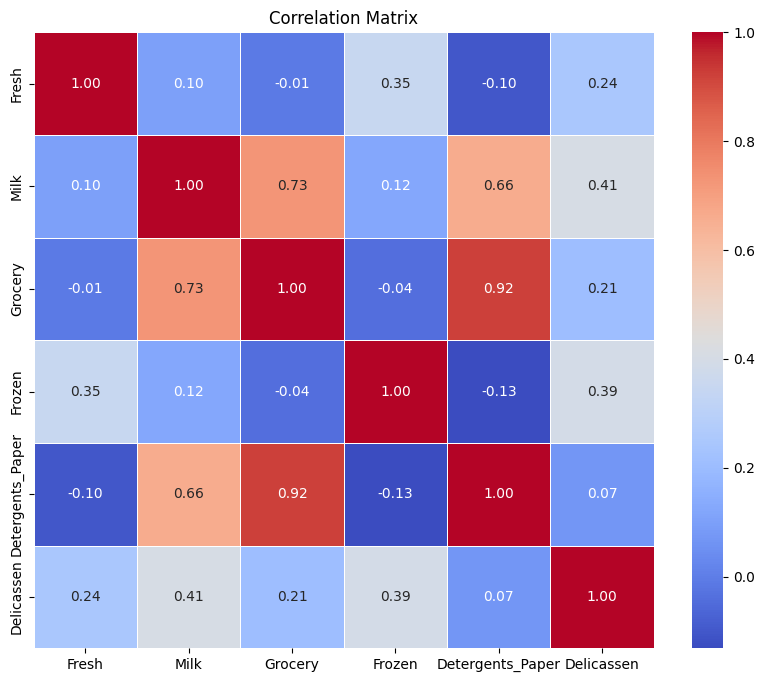

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset using the correct filename
df = pd.read_csv("Wholesale customers data.csv")

# Select numerical features only, using the correct column names
features = [
    "Fresh",
    "Milk",
    "Grocery",
    "Frozen",
    "Detergents_Paper",
    "Delicassen"
]

# Correlation matrix
corr_matrix = df[features].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.show()

In [ ]:
import pandas as pd
import numpy as np
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler

# Load dataset using the correct filename
df = pd.read_csv("Wholesale customers data.csv")

# Select numerical features
X = df[
    [
        "Fresh", # Corrected to match current dataframe column names
        "Milk", # Corrected to match current dataframe column names
        "Grocery", # Corrected to match current dataframe column names
        "Frozen", # Corrected to match current dataframe column names
        "Detergents_Paper", # Corrected to match current dataframe column names
        "Delicassen" # Corrected to match current dataframe column names
    ]
]

# Standardize features
sacler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert to DataFrame
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Calculate VIF
vif_data = pd.DataFrame()
vif_data["Feature"] = X_scaled.columns
vif_data["VIF"] = [
    variance_inflation_factor(X_scaled.values, i)
    for i in range(X_scaled.shape[1])
]

print(vif_data)

            Feature       VIF
0             Fresh  1.001896
1              Milk  1.003422
2           Grocery  1.001806
3            Frozen  1.007908
4  Detergents_Paper  1.008374
5        Delicassen  1.002032


# **Part C - Regression Analysis**

**Create a new target variable total_spend**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure 'df' has the necessary features by re-creating them if they are missing
# 1. Total spending by customer
df['Total_Spend'] = (
    df['Fresh'] +
    df['Milk'] +
    df['Grocery'] +
    df['Frozen'] +
    df['Detergents_Paper'] +
    df['Delicassen']
)

# 2. Food related spending
df['Food_Spend'] = (
    df['Fresh'] +
    df['Frozen'] +
    df['Delicassen']
)

# 3. Non-food related spending
df['Non_Food_Spend'] = (
    df['Milk'] +
    df['Grocery'] +
    df['Detergents_Paper']
)

# Corrected spending_features to match actual column names in df
spending_features = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen',
    'Food_Spend',
    'Non_Food_Spend'
]

X = df[spending_features]  # Features
y = df['Total_Spend']      # Target variable

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# **Build:**

**1.Linear Regression Model**

In [ ]:
from sklearn.linear_model import LinearRegression

# Simple Linear Regression using one feature
lin_reg = LinearRegression()

# Fit the model using 'Fresh' as the single feature
lin_reg.fit(X_train[['Fresh']], y_train)

LinearRegression()

**2.Multiple Regression model**

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Multiple Linear Regression using all features
multi_reg = LinearRegression()

# Fit the model on training data (all features)
multi_reg.fit(X_train, y_train)

# Predict on test set
y_pred = multi_reg.predict(X_test)

# **Evaluating Using**

* MAE
* RMSE
* R2 score

In [ ]:
# Evaluate the model
print("Mean Absolute Error (MAE):", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error (MSE):", mean_squared_error(y_test, y_pred))
print("R² Score:", r2_score(y_test, y_pred))

Mean Absolute Error (MAE): 5.622330883687193e-11
Mean Squared Error (MSE): 4.798249138707599e-21
R² Score: 1.0


**Apply Ridge  or Lasso and compare performance**

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:

# Ensure spending_features is defined for consistency with previous steps
spending_features = [
    'Fresh',
    'Milk',
    'Grocery',
    'Frozen',
    'Detergents_Paper',
    'Delicassen',
    'Food_Spend',
    'Non_Food_Spend'
]

X = df[spending_features]
y = df['Total_Spend']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LinearRegression()
ridge = Ridge(alpha=1.0)
lasso = Lasso(alpha=0.1)

lr.fit(X_train, y_train)
ridge.fit(X_train, y_train)
lasso.fit(X_train, y_train)

Lasso(alpha=0.1)

In [ ]:
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

In [ ]:
lr_pred = lr.predict(X_test)
ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

def evaluate(model_name, y_test, y_pred):
    print(model_name)
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("R2 Score:", r2_score(y_test, y_pred))
    print("-"*30)

evaluate("Linear Regression", y_test, lr_pred)
evaluate("Ridge Regression", y_test, ridge_pred)
evaluate("Lasso Regression", y_test, lasso_pred)

Linear Regression
MAE: 2.2806268658093884e-12
MSE: 2.4408094590106385e-23
R2 Score: 1.0
------------------------------
Ridge Regression
MAE: 2.269039429613644e-07
MSE: 1.1398829830273512e-13
R2 Score: 1.0
------------------------------
Lasso Regression
MAE: 1.2659359645654897
MSE: 3.820706438771474
R2 Score: 0.9999999922817153
------------------------------


# **Part D - Classification Modeling**

**Predict Customer Channel using**:

* Logistic Regression

* Support Vector Machine

* Decision Tree

* Random Forest

* Gradient Boosting

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:

# Ensure 'df' is the processed DataFrame from previous steps
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Total_Spend,Food_Spend,Non_Food_Spend
0,2,3,12669,9656,7561,214,2674,1338,34112,14221,19891
1,2,3,7057,9810,9568,1762,3293,1776,33266,10595,22671
2,2,3,6353,8808,7684,2405,3516,7844,36610,16602,20008
3,1,3,13265,1196,4221,6404,507,1788,27381,21457,5924
4,2,3,22615,5410,7198,3915,1777,5185,46100,31715,14385


In [ ]:
# This cell is superseded by using the main df for classification, as per the project task to predict 'Channel' from the loaded dataset.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Support Vector Machine": SVC(),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [ ]:
# This cell is superseded by using the main df for classification, as per the project task to predict 'Channel' from the loaded dataset.

In [ ]:
# Define features (X) and target (y) for classification using the main DataFrame
# 'Channel' is the target variable (1 for Horeca, 2 for Retail) as per the business problem.
X = df.drop('Channel', axis=1)   # Features are all columns except 'Channel'
y = df['Channel']                # Target is the 'Channel' column

print("Features (X) for Classification:")
print(X.head())

print("\nTarget (y) for Classification:")
print(y.head())

Features (X) for Classification:
   Region  Fresh  Milk  Grocery  Frozen  Detergents_Paper  Delicassen  \
0       3  12669  9656     7561     214              2674        1338   
1       3   7057  9810     9568    1762              3293        1776   
2       3   6353  8808     7684    2405              3516        7844   
3       3  13265  1196     4221    6404               507        1788   
4       3  22615  5410     7198    3915              1777        5185   

   Total_Spend  Food_Spend  Non_Food_Spend  
0        34112       14221           19891  
1        33266       10595           22671  
2        36610       16602           20008  
3        27381       21457            5924  
4        46100       31715           14385  

Target (y) for Classification:
0    2
1    2
2    2
3    1
4    2
Name: Channel, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, roc_auc_score, precision_score, recall_score, f1_score
import numpy as np

# X and y are now correctly defined for classification from the main df in the preceding cell (ade50d48)

# Split the data into training and testing sets, using stratification to maintain class distribution
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# models dictionary (defined in CN65sgouJN72) should be available
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    # Assuming '2' is the positive class for binary metrics (Horeca vs Retail)
    accuracy = accuracy_score(y_test, y_pred)
    # Use pos_label=2 for precision, recall, f1-score since 'Channel' labels are 1 and 2
    precision = precision_score(y_test, y_pred, pos_label=2, zero_division=0)
    recall = recall_score(y_test, y_pred, pos_label=2, zero_division=0)
    f1 = f1_score(y_test, y_pred, pos_label=2, zero_division=0)

    auc_score = np.nan
    if hasattr(model, "predict_proba"):
        y_prob = model.predict_proba(X_test_scaled)
        # Ensure positive class (2) is present in model classes
        if 2 in model.classes_ and 1 in model.classes_:
            pos_class_idx = np.where(model.classes_ == 2)[0][0]
            y_prob_positive = y_prob[:, pos_class_idx]
            auc_score = roc_auc_score(y_test, y_prob_positive)
    # Special handling for SVC if probability=True is not set or not applicable
    elif name == "SVM" and model.probability:
        y_prob = model.predict_proba(X_test_scaled)
        if 2 in model.classes_ and 1 in model.classes_:
            pos_class_idx = np.where(model.classes_ == 2)[0][0]
            y_prob_positive = y_prob[:, pos_class_idx]
            auc_score = roc_auc_score(y_test, y_prob_positive)

    results.append([name, accuracy, precision, recall, f1, auc_score])

    print(name)
    print("Accuracy:", accuracy)
    print("Precision:", precision)
    print("Recall:", recall)
    print("F1-Score:", f1)
    if not np.isnan(auc_score):
        print("ROC-AUC:", auc_score)
    print(confusion_matrix(y_test, y_pred))
    # Use zero_division to avoid warnings when no true samples or predicted samples for a class
    print(classification_report(y_test, y_pred, zero_division=0))
    print("-"*40)

Logistic Regression
Accuracy: 0.9242424242424242
Precision: 0.9024390243902439
Recall: 0.8604651162790697
F1-Score: 0.8809523809523809
ROC-AUC: 0.9568852887379148
[[85  4]
 [ 6 37]]
              precision    recall  f1-score   support

           1       0.93      0.96      0.94        89
           2       0.90      0.86      0.88        43

    accuracy                           0.92       132
   macro avg       0.92      0.91      0.91       132
weighted avg       0.92      0.92      0.92       132

----------------------------------------
Support Vector Machine
Accuracy: 0.9015151515151515
Precision: 0.8947368421052632
Recall: 0.7906976744186046
F1-Score: 0.8395061728395061
[[85  4]
 [ 9 34]]
              precision    recall  f1-score   support

           1       0.90      0.96      0.93        89
           2       0.89      0.79      0.84        43

    accuracy                           0.90       132
   macro avg       0.90      0.87      0.88       132
weighted avg       0.

# **Compare models using:**
* Accuracy
* Precision
* Recall
* F1-Score
* ROC-AUC Curve



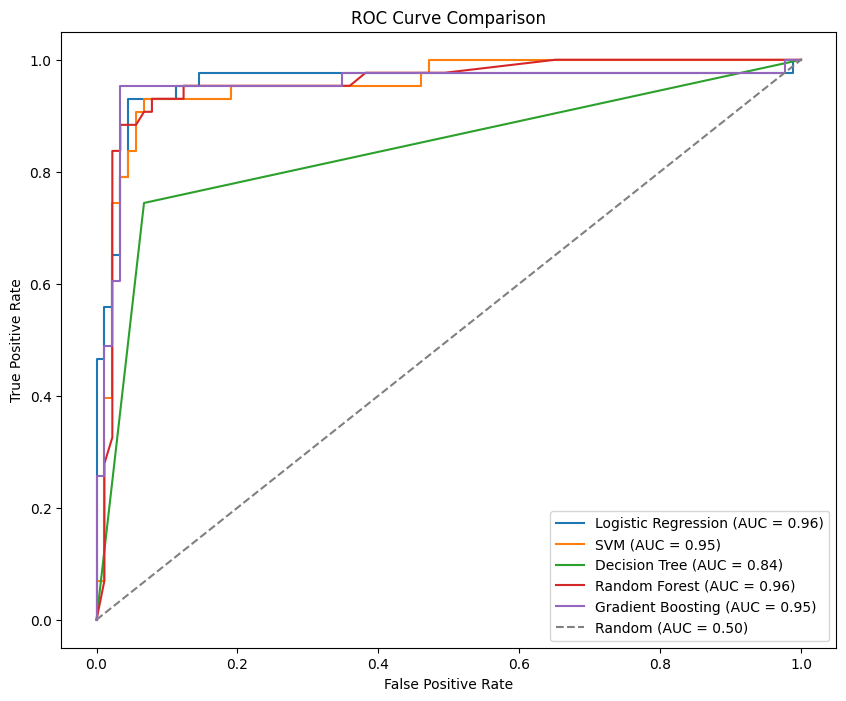

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import os
import numpy as np

# X_train_scaled, X_test_scaled, y_train, y_test are assumed to be correctly set up from s7v6z3XSJRHq now.

# Re-define models to ensure consistent parameters (e.g., random_state, probability=True for SVC)
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(probability=True, random_state=42), # probability=True is required for predict_proba
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

plt.figure(figsize=(10, 8))

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # Fit the model on the correct training data

    if hasattr(model, "predict_proba"):
        y_prob_all_classes = model.predict_proba(X_test_scaled)

        pos_label_value = 2 # Assuming '2' (Retail) is the positive class for the ROC curve
        # Check if the positive class is present in the model's learned classes
        if pos_label_value in model.classes_:
            pos_class_idx = np.where(model.classes_ == pos_label_value)[0][0]
            y_prob_positive_class = y_prob_all_classes[:, pos_class_idx]

            # roc_curve needs pos_label for non-0/1 binary labels
            fpr, tpr, _ = roc_curve(y_test, y_prob_positive_class, pos_label=pos_label_value)
            auc = roc_auc_score(y_test, y_prob_positive_class)
            plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.2f})")
        else:
            print(f"Warning: Positive class {pos_label_value} not found in model classes for {name}. Skipping ROC for this model.")
    else:
        print(f"Model {name} does not support predict_proba, skipping ROC curve.")

# Plot a random baseline for comparison
plt.plot([0, 1], [0, 1], linestyle="--", color='gray', label='Random (AUC = 0.50)')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

In [ ]:
print("Unique values in y_test:")
print(y_test.value_counts())

Unique values in y_test:
Total_Spend
57756    1
16572    1
55327    1
37566    1
4129     1
        ..
14831    1
13569    1
20897    1
35659    1
18433    1
Name: count, Length: 132, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [ ]:
# This cell is redundant as X, y, X_train, X_test, y_train, y_test, X_train_scaled, and X_test_scaled
# have already been prepared in previous classification steps using df_classification.
# The subsequent cells will now directly use X_train_scaled, X_test_scaled, y_train, y_test.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "SVM": SVC(probability=True),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

In [ ]:
results = []

for name, model in models.items():
    model.fit(X_train_scaled, y_train) # Use scaled training data
    y_pred = model.predict(X_test_scaled) # Use scaled test data
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Use scaled test data

    results.append([
        name,
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ])

In [ ]:
results_df = pd.DataFrame(
    results,
    columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]
)

print(results_df)

                 Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0  Logistic Regression  0.924242   0.934066  0.955056  0.944444  0.956885
1                  SVM  0.901515   0.904255  0.955056  0.928962  0.953227
2        Decision Tree  0.871212   0.882979  0.932584  0.907104  0.838385
3        Random Forest  0.939394   0.945055  0.966292  0.955556  0.955317
4    Gradient Boosting  0.939394   0.945055  0.966292  0.955556  0.952182


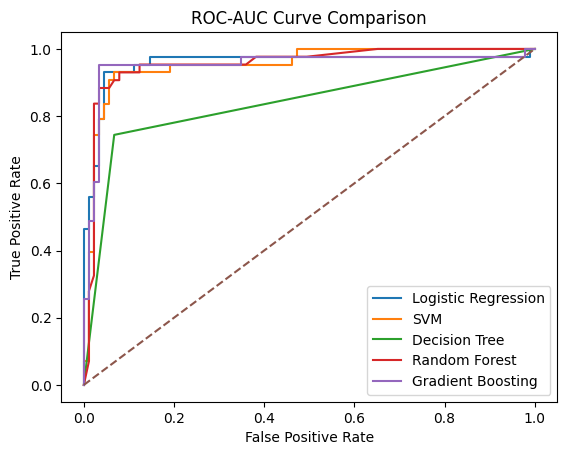

In [ ]:
plt.figure()

for name, model in models.items():
    # Ensure model is refitted or reuse the already fitted model from the evaluation loop if needed
    # For plotting ROC, we need probabilities on the test set
    y_prob = model.predict_proba(X_test_scaled)[:, 1] # Use scaled test data
    # Fix: Specify pos_label for roc_curve
    fpr, tpr, _ = roc_curve(y_test, y_prob, pos_label=2) # pos_label=2 for 'Channel' target
    plt.plot(fpr, tpr, label=name)

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC-AUC Curve Comparison")
plt.legend()
plt.show()

# **Part E-Unsupervised Learning**

* Apply K-Means Clustering to segment customers

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("Wholesale customers data.csv")

In [ ]:
X = df.drop("Channel", axis=1)

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters
df.head()

,Channel,Region,Fresh,Milk,Grocery,Frozen,Detergents_Paper,Delicassen,Cluster
0,2,3,12669,9656,7561,214,2674,1338,0
1,2,3,7057,9810,9568,1762,3293,1776,0
2,2,3,6353,8808,7684,2405,3516,7844,0
3,1,3,13265,1196,4221,6404,507,1788,0
4,2,3,22615,5410,7198,3915,1777,5185,0


**Use PCA to reduce dimensions and visualize clusters**

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
pca_df = pd.DataFrame(X_pca, columns=["PC1", "PC2"])
pca_df["Cluster"] = clusters

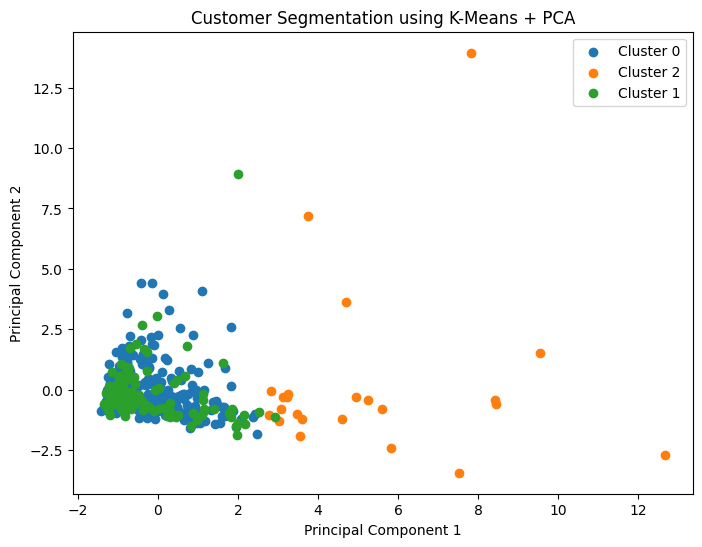

In [ ]:
plt.figure(figsize=(8,6))
for cluster in pca_df["Cluster"].unique():
    subset = pca_df[pca_df["Cluster"] == cluster]
    plt.scatter(subset["PC1"], subset["PC2"], label=f"Cluster {cluster}")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Customer Segmentation using K-Means + PCA")
plt.legend()
plt.show()

# **Part F : Model Evaluation and Insights**

## **Explain**:

 * Overfitting vs Underfitting:


Overfitting occurs when a model learns the training data too well, including noise and outliers.
Training accuracy is very high, but validation or test accuracy is low.
The model fails to generalize to new data.
Underfitting occurs when a model is too simple to capture the underlying patterns in the data.
Both training and validation accuracies are low, resulting in poor performance.

 * Train vs Validation Behavior

Training data is used to train the model and adjust its parameters.
Validation data is used to evaluate the model’s performance on unseen data.
High training accuracy and low validation accuracy indicate overfitting.
Low accuracy on both training and validation data indicates underfitting.
A good model shows similar and high performance on both training and validation datasets.

* Impact of Feature Scaling

Feature scaling brings all features to a similar range.
It helps models converge faster and perform better.
Algorithms like Linear Regression, Logistic Regression, KNN, SVM, Ridge, and Lasso are sensitive to feature scale.
Common scaling techniques include Standardization and Normalization.

* Importance of Handling Class Imbalance

Class imbalance occurs when one class has significantly more samples than other classes.
It causes the model to favor the majority class, leading to biased predictions.
Accuracy alone becomes unreliable techniques such as oversampling, undersampling, class weighting, and using metrics like Precision, Recall, and F1-score help handle imbalance effectively.